# Train GP module: CTMC → spatial inverse map, 300 targets

This notebook builds a 300-target CTMC-to-spatial matching dataset, trains the Gaussian Process inverse model,
and saves it as

```python
saved_models/gp_module.joblib
```

The saved module maps

\[
(k_{12}^{\mathrm{CTMC}}, k_{21}^{\mathrm{CTMC}})
\longmapsto
(k_{12}^{\mathrm{site}}, k_{21}^{\mathrm{base}}).
\]

The regression is trained in log-space:

\[
X=(\log k_{12}^{\mathrm{CTMC}}, \log k_{21}^{\mathrm{CTMC}}),
\qquad
Y=(\log k_{12}^{\mathrm{site}}, \log k_{21}^{\mathrm{base}}).
\]


## 1. Load local spatial model modules

In [1]:
from pathlib import Path
import importlib.util
import sys


def load_module(module_name, filename_candidates):
    search_roots = [
        Path.cwd(),
        Path.cwd() / "python_version",
        Path.cwd().parent,
        Path.cwd().parent / "python_version",
        Path("/mnt/data"),
    ]
    for root in search_roots:
        for name in filename_candidates:
            path = root / name
            if path.exists():
                spec = importlib.util.spec_from_file_location(module_name, path)
                mod = importlib.util.module_from_spec(spec)
                sys.modules[module_name] = mod
                spec.loader.exec_module(mod)
                print(f"Loaded {module_name} from {path}")
                return mod
    raise FileNotFoundError(f"Could not find {module_name} in {search_roots}")

# Load in dependency order. The parenthesized filenames are included for uploaded files.
gillespie = load_module("gillespie", ["gillespie.py", "gillespie(20).py"])
prc1 = load_module("prc1", ["prc1.py", "prc1(19).py"])
prc1_state = load_module("prc1_state", ["prc1_state.py", "prc1_state(18).py"])
run_gillespie = load_module("run_gillespie", ["run_gillespie.py", "run_gillespie(18).py"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prc1_state import State

Loaded gillespie from C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\gillespie.py
Loaded prc1 from C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\prc1.py
Loaded prc1_state from C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\prc1_state.py
Loaded run_gillespie from C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\run_gillespie.py


## 2. Fixed parameters and experiment settings

In [2]:
# Fixed spatial parameters requested
INIT_BIND = 0.000238   # first-head attachment rate per available site
K_DET_1   = 0.1        # singly bound detachment rate

# Observation grid
DT_OBS = 4.0
T_END = 68.0
times_obs = np.arange(0.0, T_END + DT_OBS, DT_OBS)

# Spatial geometry/constants, matching run_gillespie.py defaults
MICROTUBULE_LENGTH = 5000
SITE_SPACING = 8
MICROTUBULE_OFFSET = 0
SPRING_CONSTANT = 2
REST_LENGTH = 32
KBT = 4.1
MICROTUBULE_SEPARATION = 30
BASE_HOPPING_RATE = 1
NUM_SITES = int(MICROTUBULE_LENGTH / SITE_SPACING) + 1

# Default spatial model options.
# Keep cooperativity off at first. Turn on later only if that is the experiment you want.
SPATIAL_KWARGS = dict(
    cooperativity_energy=0.0,
    enable_initial_attach_cooperativity=False,
    enable_second_head_attach_cooperativity=False,
    enable_second_head_detach_cooperativity=False,
    enable_hopping=False,
    max_steps=200_000,
)

# A fixed CTMC R01 for target trajectory simulation.
# This is not part of the ML label; it is only for optional trajectory matching.
# It uses the initial available sites approximation.
R01_CTMС_FIXED = 2.0 * INIT_BIND * NUM_SITES
K10_CTMC_FIXED = K_DET_1

print("times_obs:", times_obs)
print("NUM_SITES:", NUM_SITES)
print("R01_CTMС_FIXED:", R01_CTMС_FIXED)

times_obs: [ 0.  4.  8. 12. 16. 20. 24. 28. 32. 36. 40. 44. 48. 52. 56. 60. 64. 68.]
NUM_SITES: 626
R01_CTMС_FIXED: 0.297976


## 3. Sampling ranges and matching settings

In [3]:
# Number of population/CTMC target pairs.
# Use 300 total CTMC target pairs for the matching dataset.
N_TARGETS = 300

# Number of spatial candidates searched for each CTMC target.
# This is the expensive part. Increase only after the notebook is stable.
N_SPATIAL_CANDIDATES = 20

# Spatial replicates. Increase for less noisy matching labels.
N_SPATIAL_REPS = 3

# Log-scale ranges for population/CTMC target pairs
K12_CTMC_MIN, K12_CTMC_MAX = 1.0, 30.0
K21_CTMC_MIN, K21_CTMC_MAX = 0.02, 1.0

# Log-scale ranges for spatial search candidates
K12_SITE_MIN, K12_SITE_MAX = 0.1, 20.0
K21_BASE_MIN, K21_BASE_MAX = 0.005, 1.0

# Training quality filter. This is NOT a prediction label.
# It only decides whether a best match is reliable enough to use for regression.
# We use a stricter cutoff now: only map_error <= 0.15 enters ML training.
USE_ERROR_FILTER_FOR_TRAINING = True
TRAIN_MAP_ERROR_MAX = 0.15

RANDOM_SEED = 123
rng = np.random.default_rng(RANDOM_SEED)

print("N_TARGETS:", N_TARGETS)
print("N_SPATIAL_CANDIDATES per target:", N_SPATIAL_CANDIDATES)
print("N_SPATIAL_REPS:", N_SPATIAL_REPS)

N_TARGETS: 300
N_SPATIAL_CANDIDATES per target: 20
N_SPATIAL_REPS: 3


## 4. Utility functions

In [4]:
def log_uniform(rng, low, high, size=None):
    return np.exp(rng.uniform(np.log(low), np.log(high), size=size))


def safe_log_ratio(a, b, eps=1e-12):
    return np.log((float(a) + eps) / (float(b) + eps))


def stack_runs(runs, key):
    return np.asarray([np.asarray(run[key], dtype=float) for run in runs], dtype=float)


def mean_traj(runs, key):
    return stack_runs(runs, key).mean(axis=0)


def normalized_rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    denom = np.mean(np.abs(b)) + 1e-8
    return float(np.sqrt(np.mean((a - b) ** 2)) / denom)


def combined_trajectory_error(spatial_runs, ctmc_runs):
    out = {}
    total = 0.0
    for key, weight in ERROR_WEIGHTS.items():
        err = normalized_rmse(mean_traj(spatial_runs, key), mean_traj(ctmc_runs, key))
        out[f"error_{key}"] = err
        total += float(weight) * err
    out["traj_error"] = total
    return out

## 5. CTMC simulator

In [5]:
def simulate_ctmc_one(R01, k10, k12, k21, times_obs, seed=None):
    '''Simulate the reduced CTMC and return N,n1,n2 on times_obs.'''
    rng = np.random.default_rng(seed)
    times_obs = np.asarray(times_obs, dtype=float)

    n1 = 0
    n2 = 0
    t = 0.0

    n1_out = np.zeros(len(times_obs), dtype=float)
    n2_out = np.zeros(len(times_obs), dtype=float)
    N_out = np.zeros(len(times_obs), dtype=float)

    obs_idx = 0
    while obs_idx < len(times_obs) and times_obs[obs_idx] <= 0:
        n1_out[obs_idx] = n1
        n2_out[obs_idx] = n2
        N_out[obs_idx] = n1 + n2
        obs_idx += 1

    while obs_idx < len(times_obs):
        rates = np.array([
            R01,
            k10 * n1,
            k12 * n1,
            k21 * n2,
        ], dtype=float)
        a0 = rates.sum()

        if a0 <= 0 or not np.isfinite(a0):
            # no event; fill remaining observations
            while obs_idx < len(times_obs):
                n1_out[obs_idx] = n1
                n2_out[obs_idx] = n2
                N_out[obs_idx] = n1 + n2
                obs_idx += 1
            break

        dt = rng.exponential(1.0 / a0)
        t_next = t + dt

        while obs_idx < len(times_obs) and times_obs[obs_idx] < t_next:
            n1_out[obs_idx] = n1
            n2_out[obs_idx] = n2
            N_out[obs_idx] = n1 + n2
            obs_idx += 1

        if obs_idx >= len(times_obs):
            break

        # event occurs
        t = t_next
        u = rng.random() * a0
        if u < rates[0]:
            n1 += 1
        elif u < rates[0] + rates[1]:
            if n1 > 0:
                n1 -= 1
        elif u < rates[0] + rates[1] + rates[2]:
            if n1 > 0:
                n1 -= 1
                n2 += 1
        else:
            if n2 > 0:
                n2 -= 1
                n1 += 1

    return {"times": times_obs, "n1": n1_out, "n2": n2_out, "N": N_out}


def simulate_ctmc_many(R01, k10, k12, k21, times_obs, n_reps=50, seed=1):
    rng = np.random.default_rng(seed)
    runs = []
    for _ in range(int(n_reps)):
        runs.append(
            simulate_ctmc_one(
                R01, k10, k12, k21, times_obs,
                seed=int(rng.integers(0, 2**31 - 1)),
            )
        )
    return runs

## 6. Spatial simulator with diagnostics for the original report map

In [6]:
def state_diagnostics_for_report_map(state):
    '''
    Return diagnostics at one time point.

    This implements the original report map ingredients:
      - A_spatial: average available sites per microtubule
      - m_sum_capped: sum_i min(m_i, 3) over singly bound PRC1s
      - k21_sum_actual: sum_j p_j.detachment_rate over doubly bound PRC1s
    '''
    doubly = list(state.doubly_attached_prc1)
    singly = list(state.top_attached_prc1) + list(state.bottom_attached_prc1)

    n2 = len(doubly)
    n1 = len(singly)

    A_top = len(state.top_untaken_sites)
    A_bottom = len(state.bottom_untaken_sites)
    A_spatial = 0.5 * (A_top + A_bottom)

    m_sum_capped = 0.0
    k12_actual_sum = 0.0

    # capped second-head connectivity count m_i <= 3
    for p in singly:
        k12_actual_sum += float(p.double_attachment_rate)

        closest = p.closest_index_on_other_side
        if closest is None:
            continue

        count = 0
        for offset in (-1, 0, 1):
            target = int(closest + offset)
            if target < 0 or target >= state.num_sites:
                continue

            if p.top_head_is_attached:
                # second head would bind bottom
                if target in state.bottom_untaken_sites:
                    count += 1
            elif p.bottom_head_is_attached:
                # second head would bind top
                if target in state.top_untaken_sites:
                    count += 1

        m_sum_capped += min(count, 3)

    # actual doubly-bound detachment hazards
    k21_sum_actual = float(sum(float(p.detachment_rate) for p in doubly))

    return dict(
        N=float(n1 + n2),
        n1=float(n1),
        n2=float(n2),
        A_spatial=float(A_spatial),
        m_sum_capped=float(m_sum_capped),
        k12_actual_sum=float(k12_actual_sum),
        k21_sum_actual=float(k21_sum_actual),
    )


def run_spatial_diagnostic_one(k12_site, k21_base, times_obs, seed=None, spatial_kwargs=None):
    '''Run one spatial trajectory and sample diagnostics on times_obs.'''
    np.random.seed(None if seed is None else int(seed))
    spatial_kwargs = dict(SPATIAL_KWARGS if spatial_kwargs is None else spatial_kwargs)

    state = State(
        MICROTUBULE_LENGTH,
        SITE_SPACING,
        MICROTUBULE_OFFSET,
        SPRING_CONSTANT,
        REST_LENGTH,
        KBT,
        MICROTUBULE_SEPARATION,
        INIT_BIND,
        K_DET_1,
        float(k12_site),
        float(k21_base),
        BASE_HOPPING_RATE,
        spatial_kwargs.get("cooperativity_energy", 0.0),
        spatial_kwargs.get("enable_initial_attach_cooperativity", False),
        spatial_kwargs.get("enable_second_head_attach_cooperativity", False),
        spatial_kwargs.get("enable_second_head_detach_cooperativity", False),
    )

    enable_hopping = spatial_kwargs.get("enable_hopping", False)
    max_steps = int(spatial_kwargs.get("max_steps", 200_000))
    end_time = float(np.asarray(times_obs)[-1])

    def rate_function(state):
        initial_binding_rate = state.initial_binding_rate
        if len(state) == 0:
            return [initial_binding_rate, 0, 0, 0, 0] if enable_hopping else [initial_binding_rate, 0, 0]

        rates = [initial_binding_rate] + [0] * (len(state) - 1)

        for p in state:
            rates.append(p.double_attachment_rate)
        for p in state:
            rates.append(p.detachment_rate)

        if enable_hopping:
            for p in state:
                rates.append(p.total_bottom_hopping_rate)
            for p in state:
                rates.append(p.total_top_hopping_rate)

        return rates

    def single_attach_func(state, index):
        state.single_attach_prc1()

    def double_attach_func(state, index):
        state.double_attach_prc1(index)

    def detach_func(state, index):
        state.detach_prc1(index)

    def hop_bottom_func(state, index):
        state.hop_bottom(index)

    def hop_top_func(state, index):
        state.hop_top(index)

    if enable_hopping:
        reaction_functions = [single_attach_func, double_attach_func, detach_func, hop_bottom_func, hop_top_func]
    else:
        reaction_functions = [single_attach_func, double_attach_func, detach_func]

    event_times = [0.0]
    event_stats = [state_diagnostics_for_report_map(state)]

    t = 0.0
    steps = 0
    while t < end_time and steps < max_steps:
        t = gillespie.gillespie_step(state, t, rate_function, reaction_functions)
        event_times.append(float(t))
        event_stats.append(state_diagnostics_for_report_map(state))
        steps += 1

        if not np.isfinite(t):
            raise RuntimeError("Non-finite time in spatial simulation")

    if steps >= max_steps:
        raise RuntimeError("Spatial simulation hit max_steps")

    event_times = np.asarray(event_times, dtype=float)
    times_obs = np.asarray(times_obs, dtype=float)

    out = {"times": times_obs.copy()}
    keys = event_stats[0].keys()
    for key in keys:
        arr = np.zeros(len(times_obs), dtype=float)
        for i, tt in enumerate(times_obs):
            idx = np.searchsorted(event_times, tt, side="right") - 1
            idx = max(idx, 0)
            arr[i] = event_stats[idx][key]
        out[key] = arr

    return out


def run_spatial_diagnostic_many(k12_site, k21_base, times_obs, n_reps=3, seed=1, spatial_kwargs=None):
    rng = np.random.default_rng(seed)
    runs = []
    for _ in range(int(n_reps)):
        run_seed = int(rng.integers(0, 2**31 - 1))
        runs.append(run_spatial_diagnostic_one(k12_site, k21_base, times_obs, seed=run_seed, spatial_kwargs=spatial_kwargs))
    return runs

## 7. Original report map: spatial diagnostics → CTMC effective parameters

In [7]:
def report_map_from_spatial_runs(spatial_runs, k12_site):
    '''Map spatial simulation diagnostics back to CTMC parameters using the original report map.'''
    A = stack_runs(spatial_runs, "A_spatial")
    n1 = stack_runs(spatial_runs, "n1")
    n2 = stack_runs(spatial_runs, "n2")
    m_sum = stack_runs(spatial_runs, "m_sum_capped")
    k12_actual_sum = stack_runs(spatial_runs, "k12_actual_sum")
    k21_sum = stack_runs(spatial_runs, "k21_sum_actual")

    A_hat = float(np.mean(A))
    total_n1 = float(np.sum(n1))
    total_n2 = float(np.sum(n2))
    total_m_sum = float(np.sum(m_sum))
    total_k12_actual = float(np.sum(k12_actual_sum))
    total_k21_sum = float(np.sum(k21_sum))

    if total_n1 <= 0:
        m_hat = np.nan
        k12_hat_capped = np.nan
        k12_hat_actual = np.nan
    else:
        m_hat = total_m_sum / total_n1
        k12_hat_capped = float(k12_site) * m_hat
        k12_hat_actual = total_k12_actual / total_n1

    if total_n2 <= 0:
        k21_hat_actual = np.nan
    else:
        k21_hat_actual = total_k21_sum / total_n2

    R01_hat = 2.0 * INIT_BIND * A_hat
    k10_hat = K_DET_1

    return dict(
        R01_hat=R01_hat,
        k10_hat=k10_hat,
        k12_hat_capped=k12_hat_capped,
        k12_hat_actual_diagnostic=k12_hat_actual,
        k21_hat_actual=k21_hat_actual,
        A_hat=A_hat,
        m_hat=m_hat,
        total_n1=total_n1,
        total_n2=total_n2,
    )


def map_error_to_target(mapped, k12_ctmc_target, k21_ctmc_target):
    '''Log-scale error between mapped CTMC pair and target CTMC pair.'''
    if not np.isfinite(mapped["k12_hat_capped"]) or not np.isfinite(mapped["k21_hat_actual"]):
        return np.inf

    e12 = safe_log_ratio(mapped["k12_hat_capped"], k12_ctmc_target)
    e21 = safe_log_ratio(mapped["k21_hat_actual"], k21_ctmc_target)
    return float(np.sqrt(e12 * e12 + e21 * e21))

## 8. Generate CTMC targets on a log scale

In [8]:
rng_targets = np.random.default_rng(RANDOM_SEED)

ctmc_targets = pd.DataFrame({
    "target_id": np.arange(N_TARGETS),
    "k12_ctmc_target": log_uniform(rng_targets, K12_CTMC_MIN, K12_CTMC_MAX, size=N_TARGETS),
    "k21_ctmc_target": log_uniform(rng_targets, K21_CTMC_MIN, K21_CTMC_MAX, size=N_TARGETS),
})

ctmc_targets.head()

,target_id,k12_ctmc_target,k21_ctmc_target
0,0,10.183954,0.058940
1,1,1.200882,0.174444
2,2,2.115915,0.164179
3,3,1.872145,0.108276
4,4,1.819007,0.079660


## 9. Candidate generator for spatial search

In [9]:
def generate_spatial_candidates_for_target(k12_ctmc_target, k21_ctmc_target, n_candidates, rng):
    '''
    Candidate spatial pairs.

    The rough inverse k12_site ~ k12_ctmc / 3 and k21_base ~ k21_ctmc / 2
    is used only to center some proposals. It is NOT the accepted mapping.
    The actual matching is done by running spatial simulations and applying the original report map.
    '''
    candidates = []

    # local proposals around the rough inverse guess
    k12_guess = np.clip(float(k12_ctmc_target) / 3.0, K12_SITE_MIN, K12_SITE_MAX)
    k21_guess = np.clip(float(k21_ctmc_target) / 2.0, K21_BASE_MIN, K21_BASE_MAX)

    n_local = int(0.7 * n_candidates)
    n_global = int(n_candidates) - n_local

    for _ in range(n_local):
        k12_site = k12_guess * np.exp(rng.normal(0.0, 0.6))
        k21_base = k21_guess * np.exp(rng.normal(0.0, 0.6))
        k12_site = float(np.clip(k12_site, K12_SITE_MIN, K12_SITE_MAX))
        k21_base = float(np.clip(k21_base, K21_BASE_MIN, K21_BASE_MAX))
        candidates.append((k12_site, k21_base, "local"))

    for _ in range(n_global):
        k12_site = float(log_uniform(rng, K12_SITE_MIN, K12_SITE_MAX))
        k21_base = float(log_uniform(rng, K21_BASE_MIN, K21_BASE_MAX))
        candidates.append((k12_site, k21_base, "global"))

    # include the rough inverse itself
    candidates.append((float(k12_guess), float(k21_guess), "rough_inverse"))

    return candidates

## 10. Match one CTMC target by spatial search

In [10]:
def evaluate_spatial_candidate_for_target(
    k12_ctmc_target,
    k21_ctmc_target,
    k12_site,
    k21_base,
    seed=1,
):
    """Run a spatial candidate, map it back to CTMC, and compute matching error."""
    try:
        spatial_runs = run_spatial_diagnostic_many(
            k12_site=k12_site,
            k21_base=k21_base,
            times_obs=times_obs,
            n_reps=N_SPATIAL_REPS,
            seed=seed,
            spatial_kwargs=SPATIAL_KWARGS,
        )

        mapped = report_map_from_spatial_runs(spatial_runs, k12_site=k12_site)
        map_err = map_error_to_target(mapped, k12_ctmc_target, k21_ctmc_target)

        row = dict(
            k12_site=float(k12_site),
            k21_base=float(k21_base),
            map_error=float(map_err),
            valid=True,
        )
        row.update(mapped)
        return row

    except Exception as e:
        return dict(
            k12_site=float(k12_site),
            k21_base=float(k21_base),
            map_error=np.inf,
            valid=False,
            error_message=str(e),
        )


def match_one_ctmc_target(target_id, k12_ctmc_target, k21_ctmc_target, seed=1):
    """Find the best matching spatial pair for one population/CTMC pair."""
    rng_local = np.random.default_rng(seed)

    candidates = generate_spatial_candidates_for_target(
        k12_ctmc_target,
        k21_ctmc_target,
        N_SPATIAL_CANDIDATES,
        rng_local,
    )

    rows = []
    for cand_idx, (k12_site, k21_base, cand_type) in enumerate(candidates):
        row = evaluate_spatial_candidate_for_target(
            k12_ctmc_target=k12_ctmc_target,
            k21_ctmc_target=k21_ctmc_target,
            k12_site=k12_site,
            k21_base=k21_base,
            seed=seed + cand_idx * 100,
        )
        row.update(dict(
            target_id=int(target_id),
            candidate_id=int(cand_idx),
            candidate_type=cand_type,
            k12_ctmc_target=float(k12_ctmc_target),
            k21_ctmc_target=float(k21_ctmc_target),
        ))
        rows.append(row)

    df_cand = pd.DataFrame(rows)
    df_valid = df_cand[np.isfinite(df_cand["map_error"])]

    if len(df_valid) == 0:
        best = df_cand.iloc[0].copy()
    else:
        best = df_valid.loc[df_valid["map_error"].idxmin()].copy()

    return best.to_dict(), df_cand

## 11. Run the matching search and build the regression dataset

In [11]:
all_best_rows = []
all_candidate_rows = []

for _, target in ctmc_targets.iterrows():
    target_id = int(target["target_id"])
    k12_t = float(target["k12_ctmc_target"])
    k21_t = float(target["k21_ctmc_target"])

    print(f"Target {target_id+1}/{N_TARGETS}: k12_ctmc={k12_t:.4g}, k21_ctmc={k21_t:.4g}")

    best_row, df_cand = match_one_ctmc_target(
        target_id=target_id,
        k12_ctmc_target=k12_t,
        k21_ctmc_target=k21_t,
        seed=RANDOM_SEED + target_id * 1000,
    )

    all_best_rows.append(best_row)
    all_candidate_rows.append(df_cand)

    print(
        f"  matched spatial: k12_site={best_row.get('k12_site', np.nan):.4g}, "
        f"k21_base={best_row.get('k21_base', np.nan):.4g}, "
        f"mapped k12={best_row.get('k12_hat_capped', np.nan):.4g}, "
        f"mapped k21={best_row.get('k21_hat_actual', np.nan):.4g}, "
        f"map_error={best_row.get('map_error', np.nan):.4g}"
    )


df_match = pd.DataFrame(all_best_rows)
df_candidates = pd.concat(all_candidate_rows, ignore_index=True)

print()
print("Finished matching.")
print("Median best map error:", np.nanmedian(df_match["map_error"]))
print("Good-quality matches for training:", int((df_match["map_error"] <= TRAIN_MAP_ERROR_MAX).sum()), "/", len(df_match))

df_match.head()

Target 1/300: k12_ctmc=10.18, k21_ctmc=0.05894
  matched spatial: k12_site=2.815, k21_base=0.03609, mapped k12=8.446, mapped k21=0.05738, map_error=0.189
Target 2/300: k12_ctmc=1.201, k21_ctmc=0.1744
  matched spatial: k12_site=0.4588, k21_base=0.1011, mapped k12=1.35, mapped k21=0.1706, map_error=0.1193
Target 3/300: k12_ctmc=2.116, k21_ctmc=0.1642
  matched spatial: k12_site=0.7053, k21_base=0.08209, mapped k12=2.082, mapped k21=0.1404, map_error=0.1571
Target 4/300: k12_ctmc=1.872, k21_ctmc=0.1083
  matched spatial: k12_site=0.624, k21_base=0.05414, mapped k12=1.872, mapped k21=0.09246, map_error=0.1579
Target 5/300: k12_ctmc=1.819, k21_ctmc=0.07966
  matched spatial: k12_site=0.6063, k21_base=0.03983, mapped k12=1.819, mapped k21=0.0699, map_error=0.1307
Target 6/300: k12_ctmc=15.83, k21_ctmc=0.1665
  matched spatial: k12_site=5.278, k21_base=0.08325, mapped k12=15.83, mapped k21=0.1408, map_error=0.1676
Target 7/300: k12_ctmc=23.11, k21_ctmc=0.08915
  matched spatial: k12_site=7.7

,k12_site,k21_base,map_error,valid,R01_hat,k10_hat,k12_hat_capped,k12_hat_actual_diagnostic,k21_hat_actual,A_hat,m_hat,total_n1,total_n2,target_id,candidate_id,candidate_type,k12_ctmc_target,k21_ctmc_target
0,2.815456,0.036091,0.188979,True,0.294058,0.1,8.446367,11.940619,0.057384,617.768519,3.000000,5.0,442.0,0,9,local,10.183954,0.058940
1,0.458792,0.101128,0.119269,True,0.294278,0.1,1.350160,1.886942,0.170598,618.231481,2.942857,35.0,402.0,1,9,local,1.200882,0.174444
2,0.705305,0.082090,0.157077,True,0.293485,0.1,2.082329,2.936839,0.140429,616.564815,2.952381,21.0,499.0,2,20,rough_inverse,2.115915,0.164179
3,0.624048,0.054138,0.157864,True,0.294917,0.1,1.872145,2.646649,0.092464,619.574074,3.000000,12.0,341.0,3,20,rough_inverse,1.872145,0.108276
4,0.606336,0.039830,0.130692,True,0.294979,0.1,1.819007,2.540173,0.069901,619.703704,3.000000,12.0,334.0,4,20,rough_inverse,1.819007,0.079660


## 12. Save matching results

In [12]:
out_dir = Path("ctmc_to_spatial_matching_regression_outputs")
out_dir.mkdir(exist_ok=True)

match_csv = out_dir / "matched_ctmc_to_spatial_pairs.csv"
candidates_csv = out_dir / "all_spatial_candidates.csv"

df_match.to_csv(match_csv, index=False)
df_candidates.to_csv(candidates_csv, index=False)

print("Saved:")
print(match_csv.resolve())
print(candidates_csv.resolve())

Saved:
C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\ctmc_to_spatial_matching_regression_outputs\matched_ctmc_to_spatial_pairs.csv
C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\ctmc_to_spatial_matching_regression_outputs\all_spatial_candidates.csv


## 13. Diagnostics: mapped-back CTMC pair vs target population pair

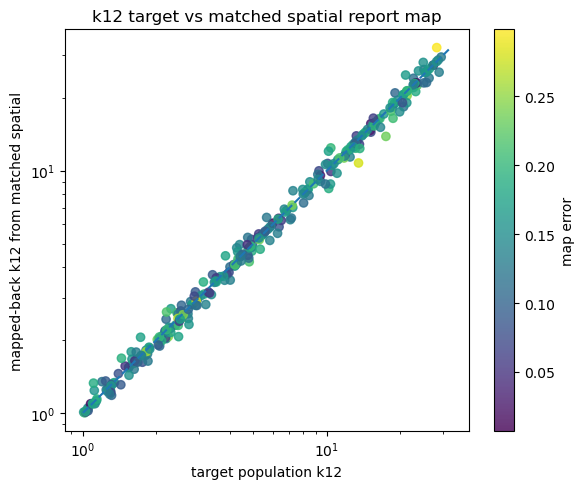

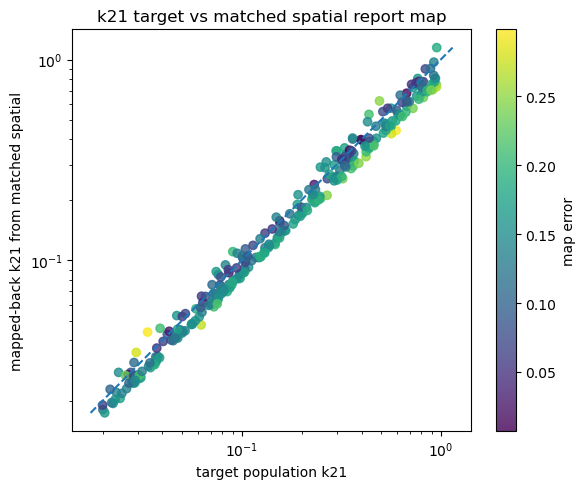

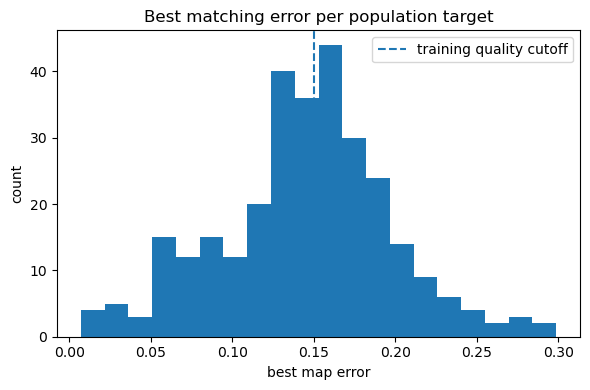

In [13]:
plt.figure(figsize=(6, 5))
sc = plt.scatter(df_match["k12_ctmc_target"], df_match["k12_hat_capped"], c=df_match["map_error"], alpha=0.8)
lo = min(df_match["k12_ctmc_target"].min(), df_match["k12_hat_capped"].min())
hi = max(df_match["k12_ctmc_target"].max(), df_match["k12_hat_capped"].max())
plt.plot([lo, hi], [lo, hi], "--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("target population k12")
plt.ylabel("mapped-back k12 from matched spatial")
plt.title("k12 target vs matched spatial report map")
plt.colorbar(sc, label="map error")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sc = plt.scatter(df_match["k21_ctmc_target"], df_match["k21_hat_actual"], c=df_match["map_error"], alpha=0.8)
lo = min(df_match["k21_ctmc_target"].min(), df_match["k21_hat_actual"].min())
hi = max(df_match["k21_ctmc_target"].max(), df_match["k21_hat_actual"].max())
plt.plot([lo, hi], [lo, hi], "--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("target population k21")
plt.ylabel("mapped-back k21 from matched spatial")
plt.title("k21 target vs matched spatial report map")
plt.colorbar(sc, label="map error")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df_match["map_error"].replace([np.inf, -np.inf], np.nan).dropna(), bins=20)
plt.axvline(TRAIN_MAP_ERROR_MAX, linestyle="--", label="training quality cutoff")
plt.xlabel("best map error")
plt.ylabel("count")
plt.title("Best matching error per population target")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Train regression model: population \((k_{12}, k_{21})\) → matched spatial \((k_{12}^{site}, k_{21}^{base})\)

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.multioutput import MultiOutputRegressor

# The ML target is the matched spatial pair, not an accepted/rejected label.
# The error filter only removes unreliable matches from the regression dataset.
df_train = df_match.replace([np.inf, -np.inf], np.nan).dropna(subset=[
    "k12_ctmc_target", "k21_ctmc_target", "k12_site", "k21_base", "map_error"
]).copy()

if USE_ERROR_FILTER_FOR_TRAINING:
    df_train = df_train[df_train["map_error"] <= TRAIN_MAP_ERROR_MAX].copy()

print("Regression training rows:", len(df_train), "out of", len(df_match))
print("Training error cutoff:", TRAIN_MAP_ERROR_MAX)

if len(df_train) < 10:
    print("Not enough matched rows for reliable regression. Increase N_TARGETS/N_SPATIAL_CANDIDATES or relax TRAIN_MAP_ERROR_MAX.")
else:
    X = np.column_stack([
        np.log(df_train["k12_ctmc_target"].to_numpy(dtype=float)),
        np.log(df_train["k21_ctmc_target"].to_numpy(dtype=float)),
    ])

    Y = np.column_stack([
        np.log(df_train["k12_site"].to_numpy(dtype=float)),
        np.log(df_train["k21_base"].to_numpy(dtype=float)),
    ])

    # Simple train/test split only. No cross-validation in this notebook.
    if len(df_train) >= 20:
        idx_all = np.arange(len(df_train))
        train_idx, test_idx = train_test_split(idx_all, test_size=0.25, random_state=1)
    else:
        idx_all = np.arange(len(df_train))
        train_idx, test_idx = idx_all, idx_all

    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    df_train_split = df_train.iloc[train_idx].copy()
    df_test_split = df_train.iloc[test_idx].copy()

    # Model 1: Random Forest
    inverse_model_rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=2,
        random_state=1,
    )
    inverse_model_rf.fit(X_train, Y_train)
    Y_pred_rf = inverse_model_rf.predict(X_test)

    # Model 2: Gaussian Process regression.
    # We use one GP per output coordinate via MultiOutputRegressor.
    gp_kernel = (
        ConstantKernel(1.0, (1e-2, 1e2))
        * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 1e-1))
    )
    inverse_model_gp = MultiOutputRegressor(
        GaussianProcessRegressor(
            kernel=gp_kernel,
            normalize_y=True,
            n_restarts_optimizer=1,
            random_state=2,
        )
    )
    inverse_model_gp.fit(X_train, Y_train)
    Y_pred_gp = inverse_model_gp.predict(X_test)

    def summarize_regression_model(name, Y_true, Y_pred):
        r2 = r2_score(Y_true, Y_pred, multioutput="raw_values")
        mae = mean_absolute_error(Y_true, Y_pred, multioutput="raw_values")
        print()
        print(name)
        print("R2  [log k12_site, log k21_base]:", r2)
        print("MAE [log k12_site, log k21_base]:", mae)
        print("Mean MAE:", float(np.mean(mae)))
        return {"name": name, "r2": r2, "mae": mae, "mean_mae": float(np.mean(mae))}

    rf_metrics = summarize_regression_model("Random Forest", Y_test, Y_pred_rf)
    gp_metrics = summarize_regression_model("Gaussian Process", Y_test, Y_pred_gp)

    # Choose the model with lower mean test MAE as the default inverse_model.
    if gp_metrics["mean_mae"] < rf_metrics["mean_mae"]:
        inverse_model = inverse_model_gp
        inverse_model_name = "Gaussian Process"
        Y_pred = Y_pred_gp
    else:
        inverse_model = inverse_model_rf
        inverse_model_name = "Random Forest"
        Y_pred = Y_pred_rf

    print()
    print("Default inverse_model:", inverse_model_name)

    X_test_plot = X_test
    Y_test_plot = Y_test
    Y_pred_plot = Y_pred
    Y_pred_rf_plot = Y_pred_rf
    Y_pred_gp_plot = Y_pred_gp


Regression training rows: 148 out of 300
Training error cutoff: 0.15


C:\Users\Khang\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Random Forest
R2  [log k12_site, log k21_base]: [0.95158626 0.97672169]
MAE [log k12_site, log k21_base]: [0.14786596 0.1607235 ]
Mean MAE: 0.15429472826957083

Gaussian Process
R2  [log k12_site, log k21_base]: [0.99357647 0.99381445]
MAE [log k12_site, log k21_base]: [0.04915938 0.0876987 ]
Mean MAE: 0.06842903734652533

Default inverse_model: Gaussian Process


C:\Users\Khang\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 15. Save the trained GP as `gp_module.joblib`

Run this cell after the GP has been trained.  It saves only the Gaussian Process inverse map, not the random forest.


In [15]:
import joblib
from pathlib import Path
from datetime import datetime

if 'inverse_model_gp' not in globals():
    raise RuntimeError("inverse_model_gp is not available. Run the training cell first.")

MODEL_DIR = Path("saved_models")
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / "gp_module.joblib"

# Store the GP and enough metadata so another notebook can use it safely.
gp_module = {
    "model": inverse_model_gp,
    "model_name": "gp_module",
    "model_type": "MultiOutputRegressor(GaussianProcessRegressor)",

    # The model convention used by predict_spatial_from_ctmc below.
    "input_space": "log_ctmc",
    "output_space": "log_spatial",
    "input_names": ["k12_ctmc", "k21_ctmc"],
    "output_names": ["k12_site", "k21_base"],

    # Dataset/settings metadata.
    "trained_on_n_targets": int(N_TARGETS),
    "n_spatial_candidates_per_target": int(N_SPATIAL_CANDIDATES),
    "n_spatial_reps": int(N_SPATIAL_REPS),
    "use_error_filter_for_training": bool(USE_ERROR_FILTER_FOR_TRAINING),
    "train_map_error_max": float(TRAIN_MAP_ERROR_MAX),
    "n_training_rows_after_filter": int(len(df_train)) if 'df_train' in globals() else None,

    # Parameter ranges used to generate/search training data.
    "k12_ctmc_bounds": [float(K12_CTMC_MIN), float(K12_CTMC_MAX)],
    "k21_ctmc_bounds": [float(K21_CTMC_MIN), float(K21_CTMC_MAX)],
    "k12_site_bounds": [float(K12_SITE_MIN), float(K12_SITE_MAX)],
    "k21_base_bounds": [float(K21_BASE_MIN), float(K21_BASE_MAX)],

    # Fixed spatial settings used when constructing labels.
    "init_bind": float(INIT_BIND),
    "k_det_1": float(K_DET_1),
    "spatial_kwargs": dict(SPATIAL_KWARGS),

    # Metrics, if available.
    "gp_metrics": {
        "r2": gp_metrics["r2"].tolist(),
        "mae": gp_metrics["mae"].tolist(),
        "mean_mae": float(gp_metrics["mean_mae"]),
    } if 'gp_metrics' in globals() else None,

    "created_at": datetime.now().isoformat(timespec="seconds"),
}

joblib.dump(gp_module, MODEL_PATH)
print("Saved GP module to:", MODEL_PATH.resolve())


Saved GP module to: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\saved_models\gp_module.joblib


## 16. Quick load test

This is the exact code you can copy into the multi-level ABC notebook.


In [16]:
import joblib
import numpy as np

loaded_gp_module = joblib.load("saved_models/gp_module.joblib")
gp_model = loaded_gp_module["model"]


def predict_spatial_from_ctmc(k12_ctmc, k21_ctmc, return_std=False):
    """
    Input: CTMC parameters on original scale.
    Output: predicted spatial parameters on original scale.
    """
    X_new = np.array([[np.log(float(k12_ctmc)), np.log(float(k21_ctmc))]], dtype=float)

    if return_std:
        # MultiOutputRegressor does not expose return_std directly, so ask each GP separately.
        means = []
        stds = []
        for est in gp_model.estimators_:
            m, s = est.predict(X_new, return_std=True)
            means.append(float(m[0]))
            stds.append(float(s[0]))
        y_log = np.array(means, dtype=float)
        y_log_std = np.array(stds, dtype=float)
        return {
            "k12_site_pred": float(np.exp(y_log[0])),
            "k21_base_pred": float(np.exp(y_log[1])),
            "log_std_k12_site": float(y_log_std[0]),
            "log_std_k21_base": float(y_log_std[1]),
        }

    y_log = gp_model.predict(X_new)[0]
    return {
        "k12_site_pred": float(np.exp(y_log[0])),
        "k21_base_pred": float(np.exp(y_log[1])),
    }

print("Loaded:", loaded_gp_module["model_name"])
print(predict_spatial_from_ctmc(10.0, 0.2))
print(predict_spatial_from_ctmc(10.0, 0.2, return_std=True))


Loaded: gp_module
{'k12_site_pred': 3.457431368172938, 'k21_base_pred': 0.1152552937818118}
{'k12_site_pred': 3.457431368172938, 'k21_base_pred': 0.1152552937818118, 'log_std_k12_site': 0.09116509551338614, 'log_std_k21_base': 0.09146292752029844}


## 17. ML diagnostic plots

These plots compare the Random Forest and Gaussian Process predictions on the same held-out test split.


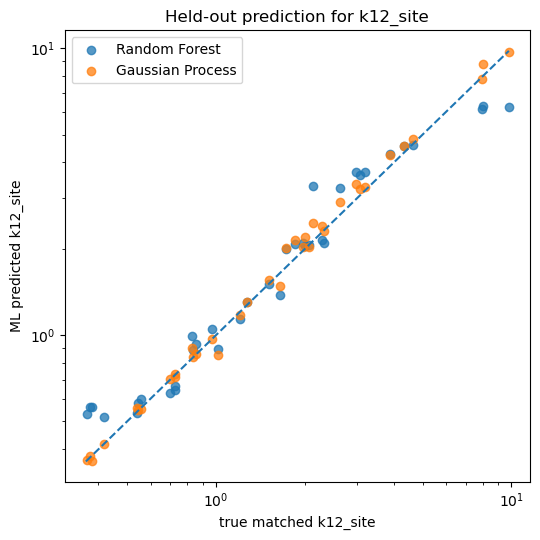

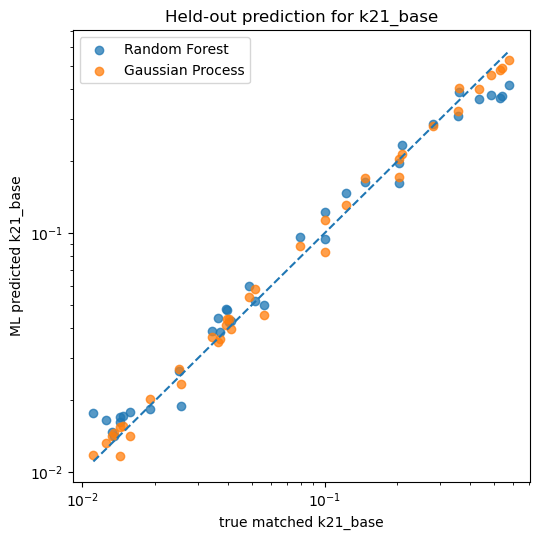

Default inverse_model: Gaussian Process

Random Forest feature importances for [log k12_ctmc, log k21_ctmc]:
[0.42512706 0.57487294]

Gaussian Process learned kernels:
output 0 (k12_site): 3.22**2 * RBF(length_scale=[5.83, 100]) + WhiteKernel(noise_level=0.00908)
output 1 (k21_base): 4.11**2 * RBF(length_scale=[100, 8.62]) + WhiteKernel(noise_level=0.00704)


In [17]:
if 'inverse_model_rf' in globals() and 'inverse_model_gp' in globals():
    labels = ["k12_site", "k21_base"]
    model_preds = {
        "Random Forest": Y_pred_rf_plot,
        "Gaussian Process": Y_pred_gp_plot,
    }

    for j, label in enumerate(labels):
        true_vals = np.exp(Y_test_plot[:, j])

        plt.figure(figsize=(5.5, 5.5))
        lo = true_vals.min()
        hi = true_vals.max()

        for model_name, Y_pred_model in model_preds.items():
            pred_vals = np.exp(Y_pred_model[:, j])
            lo = min(lo, pred_vals.min())
            hi = max(hi, pred_vals.max())
            plt.scatter(true_vals, pred_vals, alpha=0.75, label=model_name)

        plt.plot([lo, hi], [lo, hi], "--")
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel(f"true matched {label}")
        plt.ylabel(f"ML predicted {label}")
        plt.title(f"Held-out prediction for {label}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    print("Default inverse_model:", inverse_model_name)
    print()
    print("Random Forest feature importances for [log k12_ctmc, log k21_ctmc]:")
    print(inverse_model_rf.feature_importances_)

    print()
    print("Gaussian Process learned kernels:")
    for j, est in enumerate(inverse_model_gp.estimators_):
        print(f"output {j} ({labels[j]}):", est.kernel_)


## 18. Use the learned matching regression on a new population pair

In [18]:
def predict_spatial_from_population(k12_ctmc, k21_ctmc, model="default"):
    """
    Predict matched spatial k12_site and k21_base from population/CTMC k12,k21.

    model can be:
        "default" -> whichever model had lower held-out mean MAE
        "rf"      -> Random Forest
        "gp"      -> Gaussian Process
    """
    if model == "rf":
        if 'inverse_model_rf' not in globals():
            raise RuntimeError("Train inverse_model_rf first.")
        use_model = inverse_model_rf
    elif model == "gp":
        if 'inverse_model_gp' not in globals():
            raise RuntimeError("Train inverse_model_gp first.")
        use_model = inverse_model_gp
    else:
        if 'inverse_model' not in globals():
            raise RuntimeError("Train inverse_model first.")
        use_model = inverse_model

    X_new = np.array([[np.log(float(k12_ctmc)), np.log(float(k21_ctmc))]], dtype=float)
    y_log = use_model.predict(X_new)[0]
    return dict(
        k12_site_pred=float(np.exp(y_log[0])),
        k21_base_pred=float(np.exp(y_log[1])),
    )

# Example
if 'inverse_model' in globals():
    print("Default model:", inverse_model_name)
    print("default:", predict_spatial_from_population(k12_ctmc=10.0, k21_ctmc=0.2, model="default"))
    print("rf     :", predict_spatial_from_population(k12_ctmc=10.0, k21_ctmc=0.2, model="rf"))
    print("gp     :", predict_spatial_from_population(k12_ctmc=10.0, k21_ctmc=0.2, model="gp"))


Default model: Gaussian Process
default: {'k12_site_pred': 3.457431368172938, 'k21_base_pred': 0.1152552937818118}
rf     : {'k12_site_pred': 3.6110897650597025, 'k21_base_pred': 0.14525308606178403}
gp     : {'k12_site_pred': 3.457431368172938, 'k21_base_pred': 0.1152552937818118}


## 19. Optional: verify one ML prediction by running the spatial model and mapping back

In [19]:
if 'inverse_model_rf' in globals() and 'inverse_model_gp' in globals():
    k12_ctmc_test = 10.0
    k21_ctmc_test = 0.2

    for model_name in ["rf", "gp", "default"]:
        pred = predict_spatial_from_population(k12_ctmc_test, k21_ctmc_test, model=model_name)

        spatial_test_runs = run_spatial_diagnostic_many(
            pred["k12_site_pred"],
            pred["k21_base_pred"],
            times_obs,
            n_reps=N_SPATIAL_REPS,
            seed=999,
            spatial_kwargs=SPATIAL_KWARGS,
        )
        mapped_test = report_map_from_spatial_runs(spatial_test_runs, pred["k12_site_pred"])

        print("=" * 80)
        print("Model:", model_name)
        print("Target population pair:")
        print("  k12_ctmc =", k12_ctmc_test)
        print("  k21_ctmc =", k21_ctmc_test)
        print("Predicted spatial pair:")
        print(pred)
        print("Mapped back by original report map:")
        print("  k12_hat_capped =", mapped_test["k12_hat_capped"])
        print("  k21_hat_actual =", mapped_test["k21_hat_actual"])
        print("map error =", map_error_to_target(mapped_test, k12_ctmc_test, k21_ctmc_test))


Model: rf
Target population pair:
  k12_ctmc = 10.0
  k21_ctmc = 0.2
Predicted spatial pair:
{'k12_site_pred': 3.6110897650597025, 'k21_base_pred': 0.14525308606178403}
Mapped back by original report map:
  k12_hat_capped = 9.930496853914182
  k21_hat_actual = 0.2472455399612718
map error = 0.21217922752311916
Model: gp
Target population pair:
  k12_ctmc = 10.0
  k21_ctmc = 0.2
Predicted spatial pair:
{'k12_site_pred': 3.457431368172938, 'k21_base_pred': 0.1152552937818118}
Mapped back by original report map:
  k12_hat_capped = 10.372294104518815
  k21_hat_actual = 0.19597699316101316
map error = 0.04182149696909046
Model: default
Target population pair:
  k12_ctmc = 10.0
  k21_ctmc = 0.2
Predicted spatial pair:
{'k12_site_pred': 3.457431368172938, 'k21_base_pred': 0.1152552937818118}
Mapped back by original report map:
  k12_hat_capped = 10.372294104518815
  k21_hat_actual = 0.19597699316101316
map error = 0.04182149696909046
